# CLIP + SAM

In [1]:
# download model from google drive drive

# https://drive.google.com/file/d/10QQT131P5jJ6s0PQ7o-xZM3MYAzc6FDR/view?usp=sharing

# install necessary modules
import sys

!{sys.executable} -m pip install torch opencv-python Pillow
!{sys.executable} -m pip install git+https://github.com/openai/CLIP.git
!{sys.executable} -m pip install git+https://github.com/facebookresearch/segment-anything.git


[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip
  Cloning https://github.com/openai/CLIP.git to /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-ouxcnqku
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-ouxcnqku
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done

[notice] A new release of pip is available: 24.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip
  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-wf8njqgs
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-wf8njqgs


In [2]:
import cv2
from segment_anything import build_sam, SamAutomaticMaskGenerator
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import clip
import torch
import numpy as np

In [4]:
# load SAM

sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

#sam_checkpoint = "../checkpoints/sam_vit_b_01ec64.pth"
sam_checkpoint = "../checkpoints/sam_vit_l_0b3195.pth"
model_type = "vit_l"

#default
device = "cpu"

#NVIDIA
#device = "cuda"

#M1 chips
#device = "mps"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)

/Users/andriimatsevytyi/anaconda3/lib/python3.10/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


In [16]:
image_path = "../images/190605168479_01.png"

In [17]:
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
masks = mask_generator.generate(image)

In [7]:
def convert_box_xywh_to_xyxy(box):
    x1 = box[0]
    y1 = box[1]
    x2 = box[0] + box[2]
    y2 = box[1] + box[3]
    return [x1, y1, x2, y2]

In [8]:
def segment_image(image, segmentation_mask):
    image_array = np.array(image)
    
    segmented_image_array = np.zeros_like(image_array)
    segmented_image_array[segmentation_mask] = image_array[segmentation_mask]
    segmented_image = Image.fromarray(segmented_image_array)
    
    black_image = Image.new("RGB", image.size, (0, 0, 0))
    
    transparency_mask = np.zeros_like(segmentation_mask, dtype=np.uint8)
    transparency_mask[segmentation_mask] = 255
    transparency_mask_image = Image.fromarray(transparency_mask, mode='L')
    
    black_image.paste(segmented_image, mask=transparency_mask_image)
    return black_image

In [18]:
# Cut out all masks

import matplotlib.pyplot as plt

image = Image.open(image_path)
cropped_boxes = []

for mask in masks:
    
    # Access the 'segmentation' key to get the mask
    segmentation_mask = mask['segmentation']
    
    # Display the segmentation mask
    #plt.figure(figsize=(20, 20))
    #plt.imshow(segmentation_mask, cmap='gray')
    #plt.axis('off')
    #plt.show()
    cropped_boxes.append(segment_image(image, mask["segmentation"]).crop(convert_box_xywh_to_xyxy(mask["bbox"])))

In [14]:
# Load CLIP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)

In [10]:
@torch.no_grad()
def retriev(elements: list[Image.Image], positive_texts: list[str], negative_texts: list[str]) -> torch.Tensor:
    preprocessed_images = [preprocess(image).to(device) for image in elements]
    tokenized_positive_texts = clip.tokenize(positive_texts).to(device)
    tokenized_negative_texts = clip.tokenize(negative_texts).to(device)
    
    stacked_images = torch.stack(preprocessed_images)
    image_features = model.encode_image(stacked_images)
    positive_text_features = model.encode_text(tokenized_positive_texts)
    negative_text_features = model.encode_text(tokenized_negative_texts)
    
    image_features /= image_features.norm(dim=-1, keepdim=True)
    positive_text_features /= positive_text_features.norm(dim=-1, keepdim=True)
    negative_text_features /= negative_text_features.norm(dim=-1, keepdim=True)
    
    positive_probs = 100. * image_features @ positive_text_features.T
    negative_probs = 100. * image_features @ negative_text_features.T
    
    avg_positive_probs = positive_probs.mean(dim=1)
    avg_negative_probs = negative_probs.mean(dim=1)
    
    final_probs = avg_positive_probs - avg_negative_probs
    
    return final_probs.softmax(dim=0)

In [11]:
def get_indices_of_values_above_threshold(scores, threshold):
    return torch.nonzero(scores > threshold).squeeze().tolist()

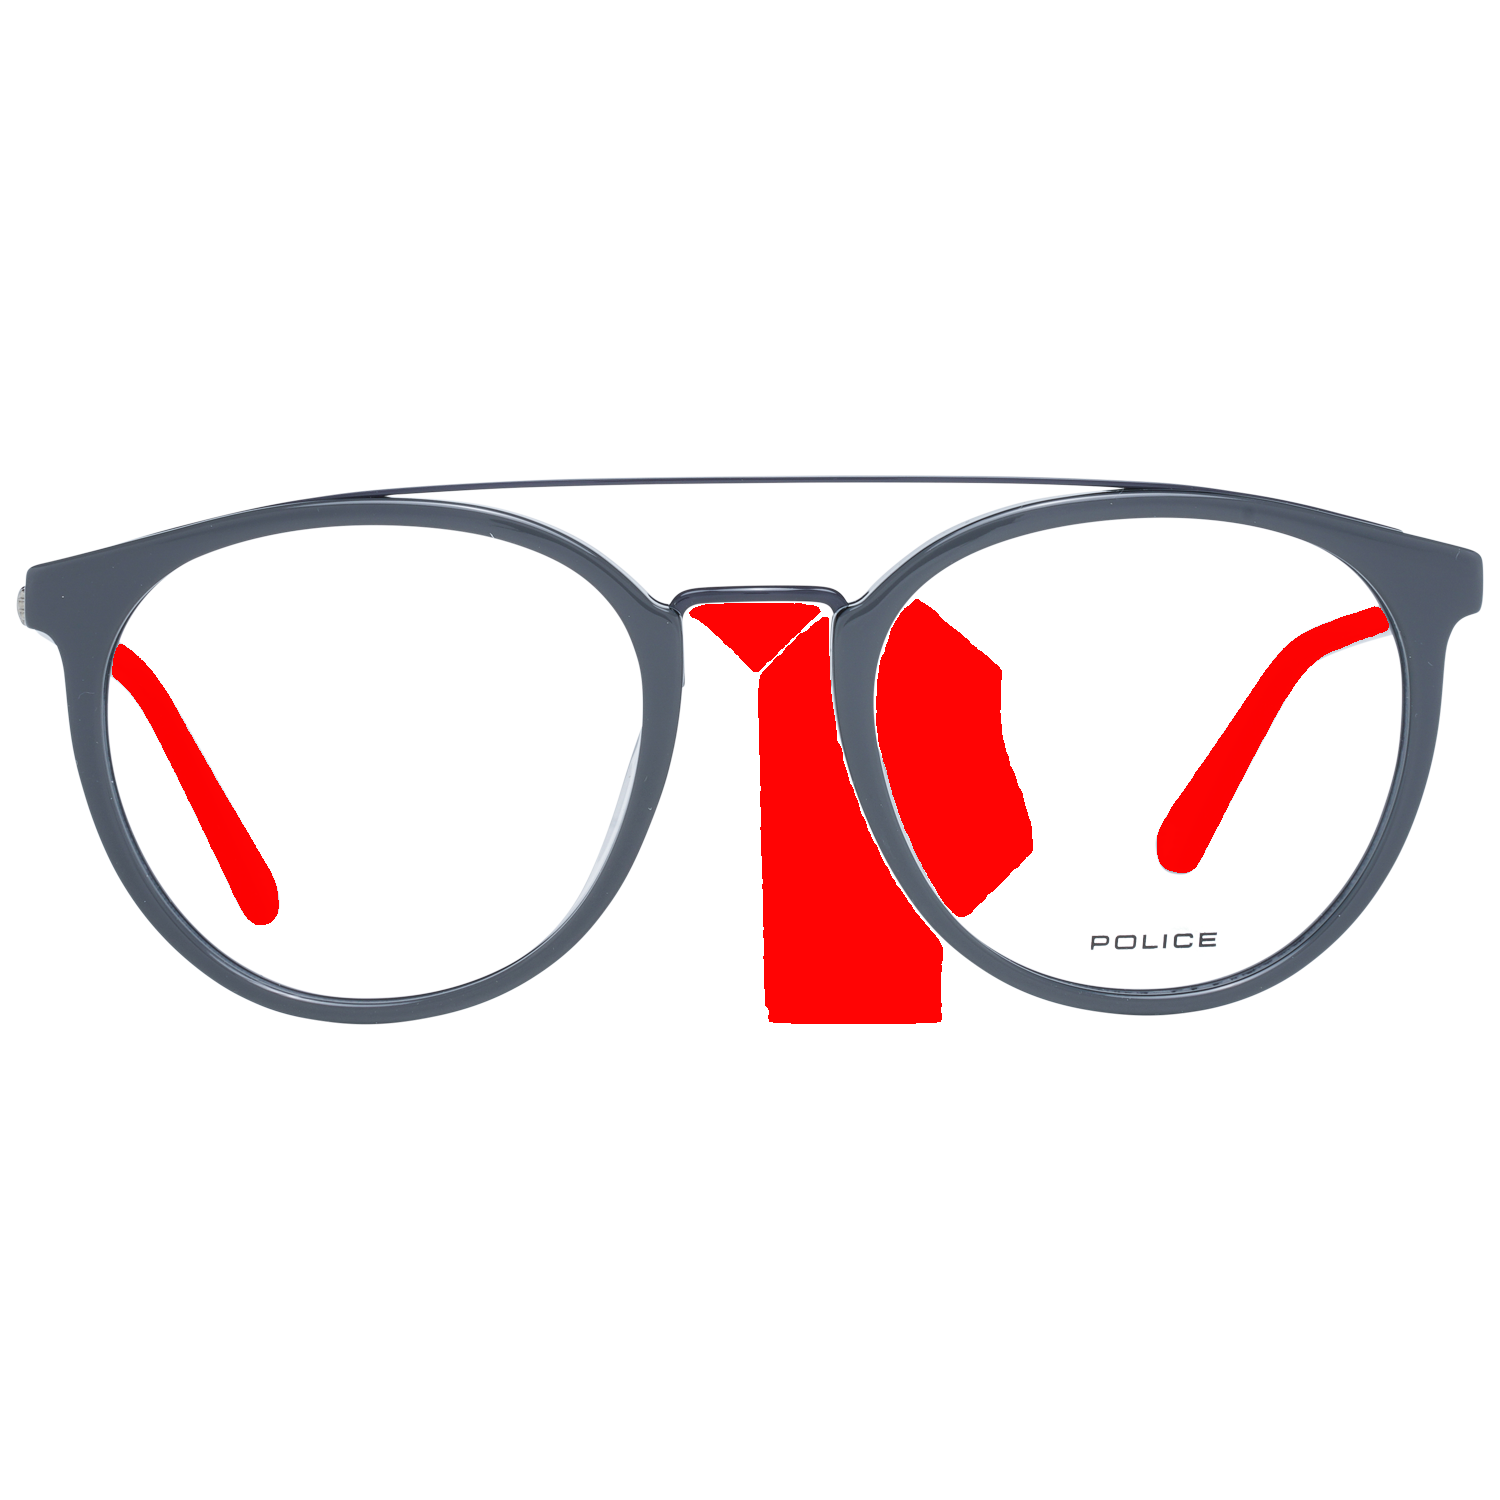

In [34]:
#scores = retriev(cropped_boxes, "temple arms")
positive_texts = ["side arms", "temple arms"]
negative_texts = ["top bar"]
scores = retriev(cropped_boxes, positive_texts, negative_texts)
indices = get_indices_of_values_above_threshold(scores, 0.05)

segmentation_masks = []

for seg_idx in indices:
    segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
    segmentation_masks.append(segmentation_mask_image)
    

original_image = Image.open(image_path)
overlay_image = Image.new('RGBA', image.size, (0, 0, 0, 0))
overlay_color = (255, 0, 0, 250)

draw = ImageDraw.Draw(overlay_image)
for segmentation_mask_image in segmentation_masks:
    draw.bitmap((0, 0), segmentation_mask_image, fill=overlay_color)

result_image = Image.alpha_composite(original_image.convert('RGBA'), overlay_image)
result_image

In [42]:
# wrapping into he function
def process_with_NLP(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    masks = mask_generator.generate(image)
    
    image = Image.open(image_path)
    cropped_boxes = []

    for mask in masks:
        
        # Access the 'segmentation' key to get the mask
        segmentation_mask = mask['segmentation']
        
        # Display the segmentation mask
        #plt.figure(figsize=(20, 20))
        #plt.imshow(segmentation_mask, cmap='gray')
        #plt.axis('off')
        #plt.show()
        cropped_boxes.append(segment_image(image, mask["segmentation"]).crop(convert_box_xywh_to_xyxy(mask["bbox"])))
        
        
    positive_texts = ["side arms", "temple arms"]
    negative_texts = ["top bar"]
    scores = retriev(cropped_boxes, positive_texts, negative_texts)
    indices = get_indices_of_values_above_threshold(scores, 0.05)
    


    segmentation_masks = []

    for seg_idx in indices:
        segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
        segmentation_masks.append(segmentation_mask_image)
        

    combined_mask = Image.new('L', image.size, 0)
    for mask in segmentation_masks:
        combined_mask.paste(mask, (0, 0), mask)
    
    # Make the selected region transparent by modifying the alpha channel
    image_rgba = image.convert('RGBA')
    np_image = np.array(image_rgba)
    np_mask = np.array(combined_mask)

    # Set the alpha channel to 0 for the selected region
    np_image[:, :, 3] = np.where(np_mask == 255, 0, np_image[:, :, 3])

    # Convert back to Image
    result_image = Image.fromarray(np_image)
    
    return result_image

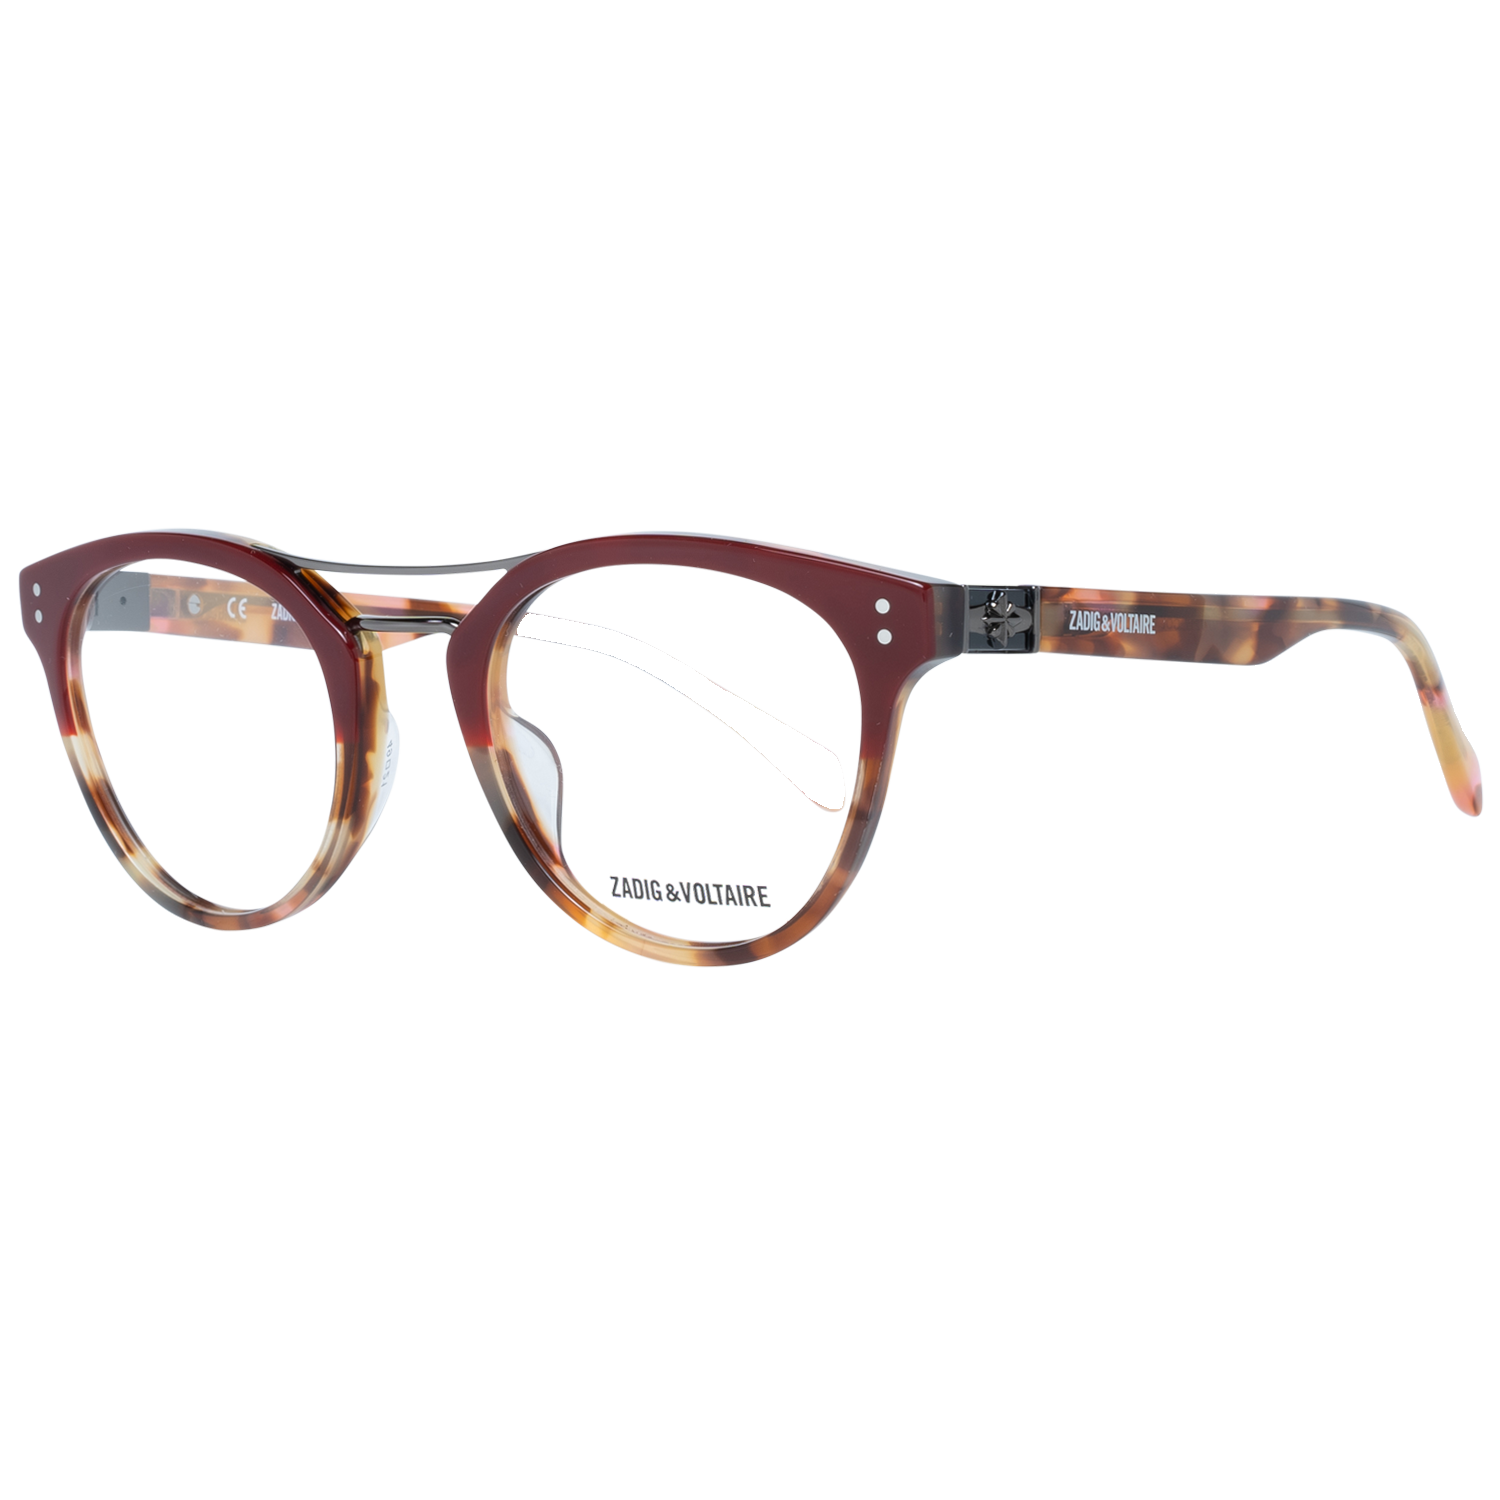

In [43]:
# example usage
result = process_with_NLP("../images/190605154304_00.png")
result

In [ ]:
import os

folder_path = '../images'
output_folder_path = '../output/preserve_nose_bar'

png_files = [f for f in os.listdir(folder_path) if f.endswith('.png')]

for file_name in png_files:
    file_path = os.path.join(folder_path, file_name)
        
   # Apply the process_with_NLP function
    result = process_with_NLP(file_path)

    
    # Display the result
    plt.figure(figsize=(10, 10))
    plt.title(f'Result for {file_name} - 1 time applied', fontsize=20)
    plt.imshow(result)
    plt.axis('off')
    plt.show()
    
    output_file_path = os.path.join(output_folder_path, file_name)
    result.save(output_file_path)
    
    """
    cv2.imwrite('temp.png', np.array(result))
    
    result = process_with_NLP('temp.png')
    
        
    # Display the result
    plt.figure(figsize=(10, 10))
    plt.title(f'Result for {file_name} - 2 times applied', fontsize=20)
    plt.imshow(result)
    plt.axis('off')
    plt.show()
    
    cv2.imwrite('temp.png', np.array(result))
    
    result = process_with_NLP('temp.png')
        
    # Display the result
    plt.figure(figsize=(10, 10))
    plt.title(f'Result for {file_name} - 3 times applied', fontsize=20)
    plt.imshow(result)
    plt.axis('off')
    plt.show()
    
    """